In [1]:
#4.2: Analyzing Data
#2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#3
exoplanet = pd.read_csv("exoplanet_data.csv", comment="#")

#4
print(exoplanet.shape) #585 rows and 92 columns
print(exoplanet.columns) #5 unknown columns: st_refname, st_radlim, sy_kmagerr, rastr, st_eff (most of them tbh)

(585, 92)
Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 's

In [2]:
#4.3: Reducing Data
#3
"""
Planet Name: pl_name, the most commonly used name for the planet in scientific literature
Host Name: hostname, the most commonly used name for the star the planet orbits around
Discovery Method: discoverymethod, the method used to detect the exoplanet
Spectral Type: st_spectype, the stellar spectral type of the host star
Equilibrium Temperature: pl_eqt, the temperature of the planet
Planet Mass: pl_bmassj, the mass of the planet
"""

#4
exoplanet_small = exoplanet[["pl_name", "hostname", "discoverymethod", "st_spectype", "pl_eqt", "pl_bmassj"]].dropna()
print(exoplanet_small.shape)
print(exoplanet_small.head)
print(exoplanet_small.tail)
print(exoplanet_small.columns)
#The smaller dataset is only 71x6


(71, 6)
<bound method NDFrame.head of          pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
3       DMPP-1 b     DMPP-1  Radial Velocity        F8 V   877.0   0.076362
5       DMPP-1 c     DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
7       DMPP-1 d     DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
8       DMPP-1 e     DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
10      DMPP-2 b     DMPP-2  Radial Velocity        F5 V  1000.0   0.437000
..           ...        ...              ...         ...     ...        ...
563   WASP-185 b   WASP-185          Transit        G0 V  1160.0   0.980000
567   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0   1.000000
573   WASP-192 b   WASP-192          Transit        G0 V  1620.0   2.300000
574       XO-7 b       XO-7          Transit        G0 V  1743.0   0.709000
583  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0   6.310000

[71 rows x 6 columns]>
<bound method NDFrame.tail

discoverymethod
Transit            56
Radial Velocity    13
Imaging             2
Name: count, dtype: int64

Different discovery methods: ['Radial Velocity' 'Transit' 'Imaging']

Method with most discoveries: Transit (56 planets)
Method with least discoveries: Imaging (2 planets)


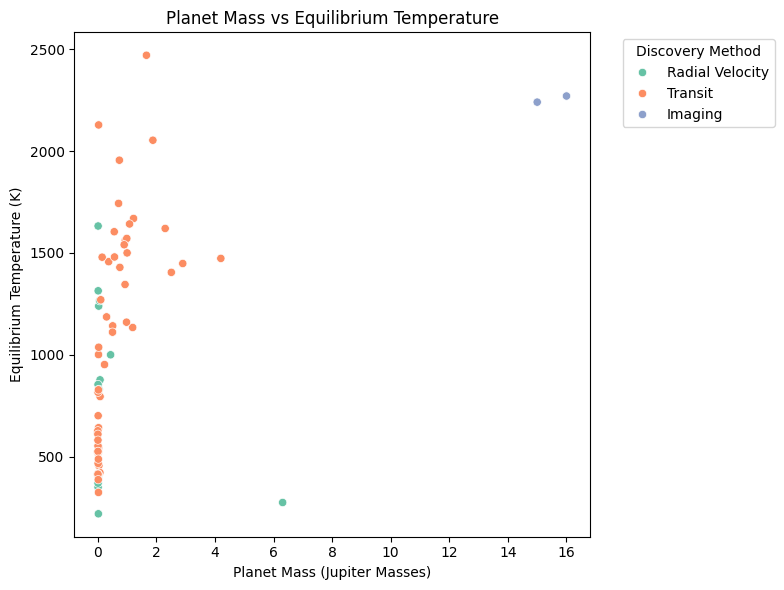

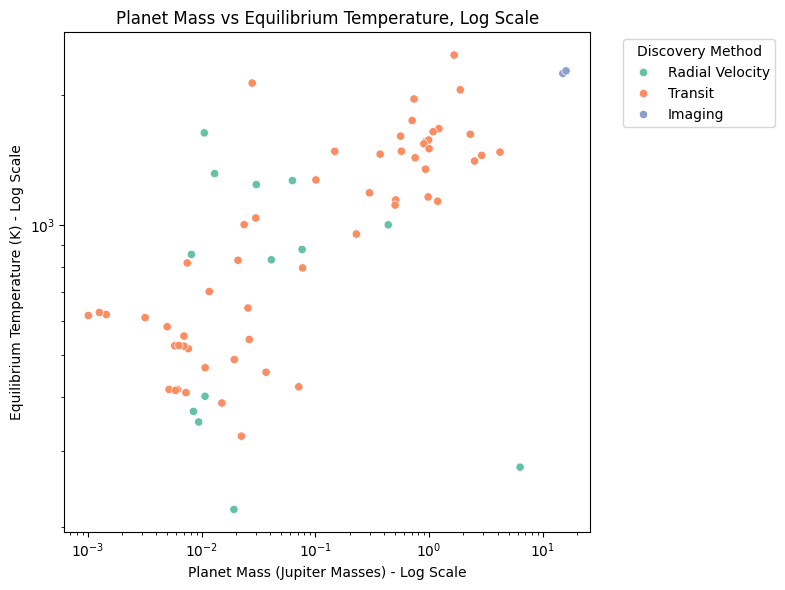

In [3]:
#4.4: Analyze Data
#1
method_counts = exoplanet_small["discoverymethod"].value_counts()
print(method_counts)
print(f"\nDifferent discovery methods: {exoplanet_small["discoverymethod"].unique()}")
print(f"\nMethod with most discoveries: {method_counts.idxmax()} ({method_counts.max()} planets)")
print(f"Method with least discoveries: {method_counts.idxmin()} ({method_counts.min()} planets)")
"""
Transit: the planet goes in front of the star and block's some of its light, which we can detect in its light curve
Radial Velocity: the star has motion away and towards us at periodic intervals, meaning there is a planet's gravity present
Direct Imaging: rare, but for close planets we can directly take a picture of them
"""

#2
plt.figure(figsize=(8, 6))
sns.scatterplot(data=exoplanet_small, x="pl_bmassj", y="pl_eqt", hue="discoverymethod", palette="Set2")
plt.title("Planet Mass vs Equilibrium Temperature")
plt.xlabel("Planet Mass (Jupiter Masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend(title="Discovery Method", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#3
plt.figure(figsize=(8, 6))
sns.scatterplot(data=exoplanet_small, x="pl_bmassj", y="pl_eqt", hue="discoverymethod", palette="Set2")
plt.xscale('log')
plt.yscale('log')
plt.title("Planet Mass vs Equilibrium Temperature, Log Scale")
plt.xlabel("Planet Mass (Jupiter Masses) - Log Scale")
plt.ylabel("Equilibrium Temperature (K) - Log Scale")
plt.legend(title="Discovery Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#4
#Based on the tables, the only planets directly imaged were very massive

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 583, dtype: object


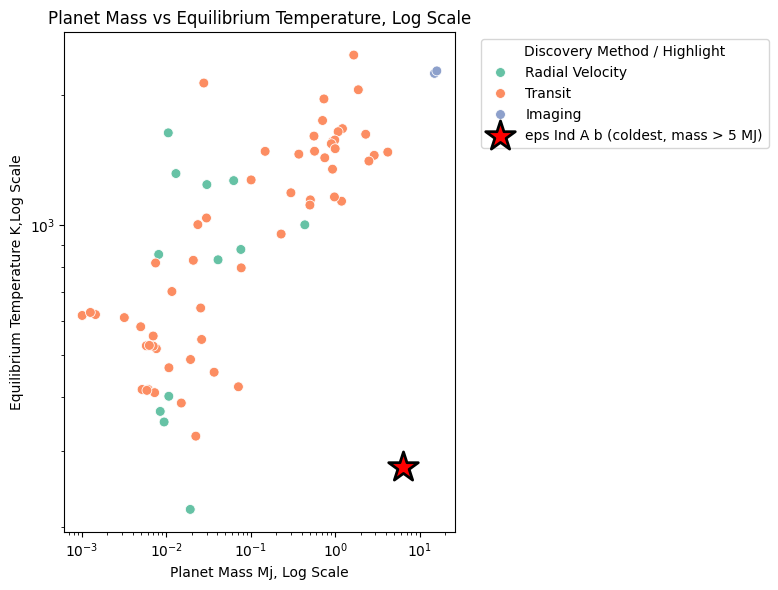

In [4]:
#5
massive_planets = exoplanet_small[exoplanet_small["pl_bmassj"] > 5]
coldest_idx = massive_planets["pl_eqt"].idxmin()
coldest_planet = exoplanet_small.loc[coldest_idx]

#6
print(coldest_planet)
"""
name: eps Ind A b
index: 583
temperature: 275K
mass: 6.31 Mj
star: K5 V, this is an orange dwarf a bit cooler than the sun
"""

#7
plt.figure(figsize=(8, 6))
sns.scatterplot(data=exoplanet_small, x="pl_bmassj", y="pl_eqt", hue="discoverymethod", palette="Set2", s=50)
plt.scatter(coldest_planet['pl_bmassj'], coldest_planet['pl_eqt'], 
            color='red', marker='*', s=500, 
            label=f"{coldest_planet['pl_name']} (coldest, mass > 5 MJ)", 
            edgecolors='black', linewidths=2, zorder=5)
plt.xscale('log')
plt.yscale('log')
plt.title("Planet Mass vs Equilibrium Temperature, Log Scale")
plt.xlabel("Planet Mass Mj, Log Scale")
plt.ylabel("Equilibrium Temperature K,Log Scale")
plt.legend(title="Discovery Method / Highlight", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [5]:
#4.5: Check your answer
"""
title: A temperate super-Jupiter imaged with JWST in the mid-infrared
abstract: A planet that wasn't a hot jupiter has been imaged for the first time, and none like it have been discovered before
answer: Yes, I also got eps Ind A b!
special: It's temperature is way lower than the other two planets discovered via imaging
mass and temp: Yes, my data is the same as the ones published in the paper
"""

"\ntitle: A temperate super-Jupiter imaged with JWST in the mid-infrared\nabstract: A planet that wasn't a hot jupiter has been imaged for the first time, and none like it have been discovered before\nanswer: Yes, I also got eps Ind A b!\nspecial: It's temperature is way lower than the other two planets discovered via imaging\nmass and temp: Yes, my data is the same as the ones published in the paper\n"